# 🚀 Fine-Tuning Backbone Architectures with Progressive Unfreezing
ResNet50, EfficientNetB0, MobileNetV3, VGG16, DenseNet201 - Full Training Pipeline

## 1️⃣ Setup & Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

✅ All imports successful
Using device: cpu


## 2️⃣ Load Data & Create DataLoaders

In [2]:
print("Loading data...")
image_dir = Path('train-images')
available_images = sorted([int(p.stem) for p in image_dir.glob('*.png')])

images_list = []
for idx in tqdm(available_images, desc='Loading images'):
    img = cv2.imread(str(image_dir / f'{idx}.png'), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        images_list.append((img / 255.0).astype(np.float32))

images_np = np.array(images_list)

# Load labels
labels_df = pd.read_csv('y_train.csv', index_col=0).T
labels_2d = labels_df.iloc[:len(images_np)].values.reshape(-1, 256, 256).astype(np.int64)

NUM_CLASSES = len(np.unique(labels_2d))

print(f"\n📊 Data Statistics:")
print(f"   Images: {images_np.shape}")
print(f"   Labels: {labels_2d.shape}")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Class distribution: {np.bincount(labels_2d.flatten())}")

Loading data...


Loading images: 100%|██████████| 1358/1358 [00:02<00:00, 580.81it/s]



📊 Data Statistics:
   Images: (1358, 256, 256)
   Labels: (1358, 256, 256)
   Classes: 55
   Class distribution: [83046868      926      673   115092   208579   201305   283963     4723
     4422   247582    19671    17542   320273     7937     6131     7501
    65158    55008    63491    68319    11931    14037   330252    90404
    76409     1977     1859     4612     5045     9206     6423    87612
    86498    28015    47374    55493   550923   781124   925175    20693
     5564    36685    53261    50937    76503    17677    14275   315423
    72506   111266    13885    28022    51741   110911   159006]


## 3️⃣ Create Dataset & DataLoaders

In [3]:
class SegmentationDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        # Convert grayscale to RGB
        self.images = torch.from_numpy(images)  # (N, 256, 256)
        self.images = torch.stack([self.images, self.images, self.images], dim=1)  # (N, 3, 256, 256)
        self.labels = torch.from_numpy(labels).long()  # (N, 256, 256)
        self.augment = augment
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = self.images[idx]
        lbl = self.labels[idx]
        
        # Simple augmentation: random flip
        if self.augment and np.random.rand() > 0.5:
            img = torch.flip(img, dims=[1])
            lbl = torch.flip(lbl, dims=[0])
        
        return img, lbl

# Split data: 80% train, 20% val
train_size = int(0.8 * len(images_np))
val_size = len(images_np) - train_size

train_dataset = SegmentationDataset(images_np[:train_size], labels_2d[:train_size], augment=True)
val_dataset = SegmentationDataset(images_np[train_size:], labels_2d[train_size:], augment=False)

BATCH_SIZE = 4  # Small batch size for fine-tuning
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"📦 Batch size: {BATCH_SIZE}")

✅ Train: 1086 | Val: 272
📦 Batch size: 4


## 4️⃣ Build Model Classes with Segmentation Head

In [4]:
class SegmentationHead(nn.Module):
    """Simple segmentation head for backbone feature maps"""
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 256, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(0.2)
        self.conv2 = nn.Conv2d(256, num_classes, 1)
        self.up = nn.Upsample(scale_factor=32, mode='bilinear', align_corners=False)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.up(x)
        return x

class ResNet50Seg(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.resnet50(pretrained=True)
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.head = SegmentationHead(2048, num_classes)
    
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.head(x)
        return x
    
    def freeze_backbone(self):
        for param in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in param.parameters():
                p.requires_grad = False
    
    def unfreeze_last_layers(self, num_blocks=2):
        # Unfreeze last num_blocks blocks
        if num_blocks >= 1:
            for p in self.layer4.parameters():
                p.requires_grad = True
        if num_blocks >= 2:
            for p in self.layer3.parameters():
                p.requires_grad = True

class EfficientNetB0Seg(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.efficientnet_b0(pretrained=True)
        self.features = backbone.features
        self.head = SegmentationHead(1280, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x
    
    def freeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = False
    
    def unfreeze_last_layers(self, num_blocks=2):
        # Unfreeze last 2 blocks
        for param in list(self.features.parameters())[-20:]:
            param.requires_grad = True

class MobileNetV3Seg(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.mobilenet_v3_small(pretrained=True)
        self.features = backbone.features
        self.head = SegmentationHead(576, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x
    
    def freeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = False
    
    def unfreeze_last_layers(self, num_blocks=2):
        for param in list(self.features.parameters())[-15:]:
            param.requires_grad = True

class VGG16Seg(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.vgg16(pretrained=True)
        self.features = backbone.features
        self.head = SegmentationHead(512, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x
    
    def freeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = False
    
    def unfreeze_last_layers(self, num_blocks=2):
        for param in list(self.features.parameters())[-10:]:
            param.requires_grad = True

class DenseNet201Seg(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.densenet201(pretrained=True)
        self.features = backbone.features
        self.head = SegmentationHead(1920, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x
    
    def freeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = False
    
    def unfreeze_last_layers(self, num_blocks=2):
        for param in list(self.features.parameters())[-30:]:
            param.requires_grad = True

print("✅ All model classes defined")

✅ All model classes defined


## 5️⃣ Training Functions with Progressive Unfreezing

In [5]:
# Compute class weights
class_counts = np.bincount(labels_2d.flatten(), minlength=NUM_CLASSES)
class_weights = torch.from_numpy(1.0 / (class_counts + 1e-6)).float().to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.numel()
    
    return total_loss / len(loader), correct / total

def train_with_unfreezing(model, train_loader, val_loader, criterion, device, model_name):
    """Train with progressive unfreezing strategy"""
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    
    # PHASE 1: Freeze backbone, train only head (5 epochs, lr=1e-3)
    print(f"\n  📍 PHASE 1: Freeze backbone (5 epochs, lr=1e-3)")
    model.freeze_backbone()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                            lr=1e-3, weight_decay=1e-5)
    
    for epoch in range(5):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"    Epoch {epoch+1}/5 | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Acc: {val_acc:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_{model_name}_phase1.pth')
            patience_counter = 0
        else:
            patience_counter += 1
    
    # PHASE 2: Unfreeze last layers, fine-tune (10 epochs, lr=1e-4)
    print(f"  📍 PHASE 2: Unfreeze last layers (10 epochs, lr=1e-4)")
    model.unfreeze_last_layers(num_blocks=2)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    patience_counter = 0
    
    for epoch in range(10):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"    Epoch {epoch+1}/10 | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Acc: {val_acc:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_{model_name}_phase2.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"    ⏹️ Early stopping at epoch {epoch+1}")
                break
    
    return history

print("✅ Training functions ready")

✅ Training functions ready


## 6️⃣ Train All Models

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights, reduction='mean')

# Train only ResNet50 and DenseNet201
model_configs = [
    ('ResNet50', ResNet50Seg),
    ('DenseNet201', DenseNet201Seg)
]

all_histories = {}
all_models = {}
training_times = {}

for model_name, ModelClass in model_configs:
    print(f"\n{'='*70}")
    print(f"🚀 Training {model_name}...")
    print(f"{'='*70}")
    
    start_time = time.time()
    
    model = ModelClass(num_classes=NUM_CLASSES).to(DEVICE)
    params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  📊 Parameters: {params:.1f}M")
    
    history = train_with_unfreezing(model, train_loader, val_loader, criterion, DEVICE, model_name)
    
    training_time = time.time() - start_time
    training_times[model_name] = training_time
    all_histories[model_name] = history
    all_models[model_name] = model
    
    print(f"  ✅ Training time: {training_time/60:.1f} minutes")

print(f"\n{'='*70}")
print("✅ TRAINING COMPLETE!")
print(f"{'='*70}")


🚀 Training DenseNet201...
  📊 Parameters: 22.5M

  📍 PHASE 1: Freeze backbone (5 epochs, lr=1e-3)
    Epoch 1/5 | Train: 3.7583 | Val: 2.8643 | Acc: 0.2503
    Epoch 2/5 | Train: 3.2562 | Val: 2.4557 | Acc: 0.3699
    Epoch 3/5 | Train: 3.0348 | Val: 3.0649 | Acc: 0.1436
    Epoch 4/5 | Train: 2.7865 | Val: 3.0083 | Acc: 0.1627
    Epoch 5/5 | Train: 2.6303 | Val: 2.8176 | Acc: 0.2283
  📍 PHASE 2: Unfreeze last layers (10 epochs, lr=1e-4)


KeyboardInterrupt: 

## 7️⃣ Visualize Training Curves

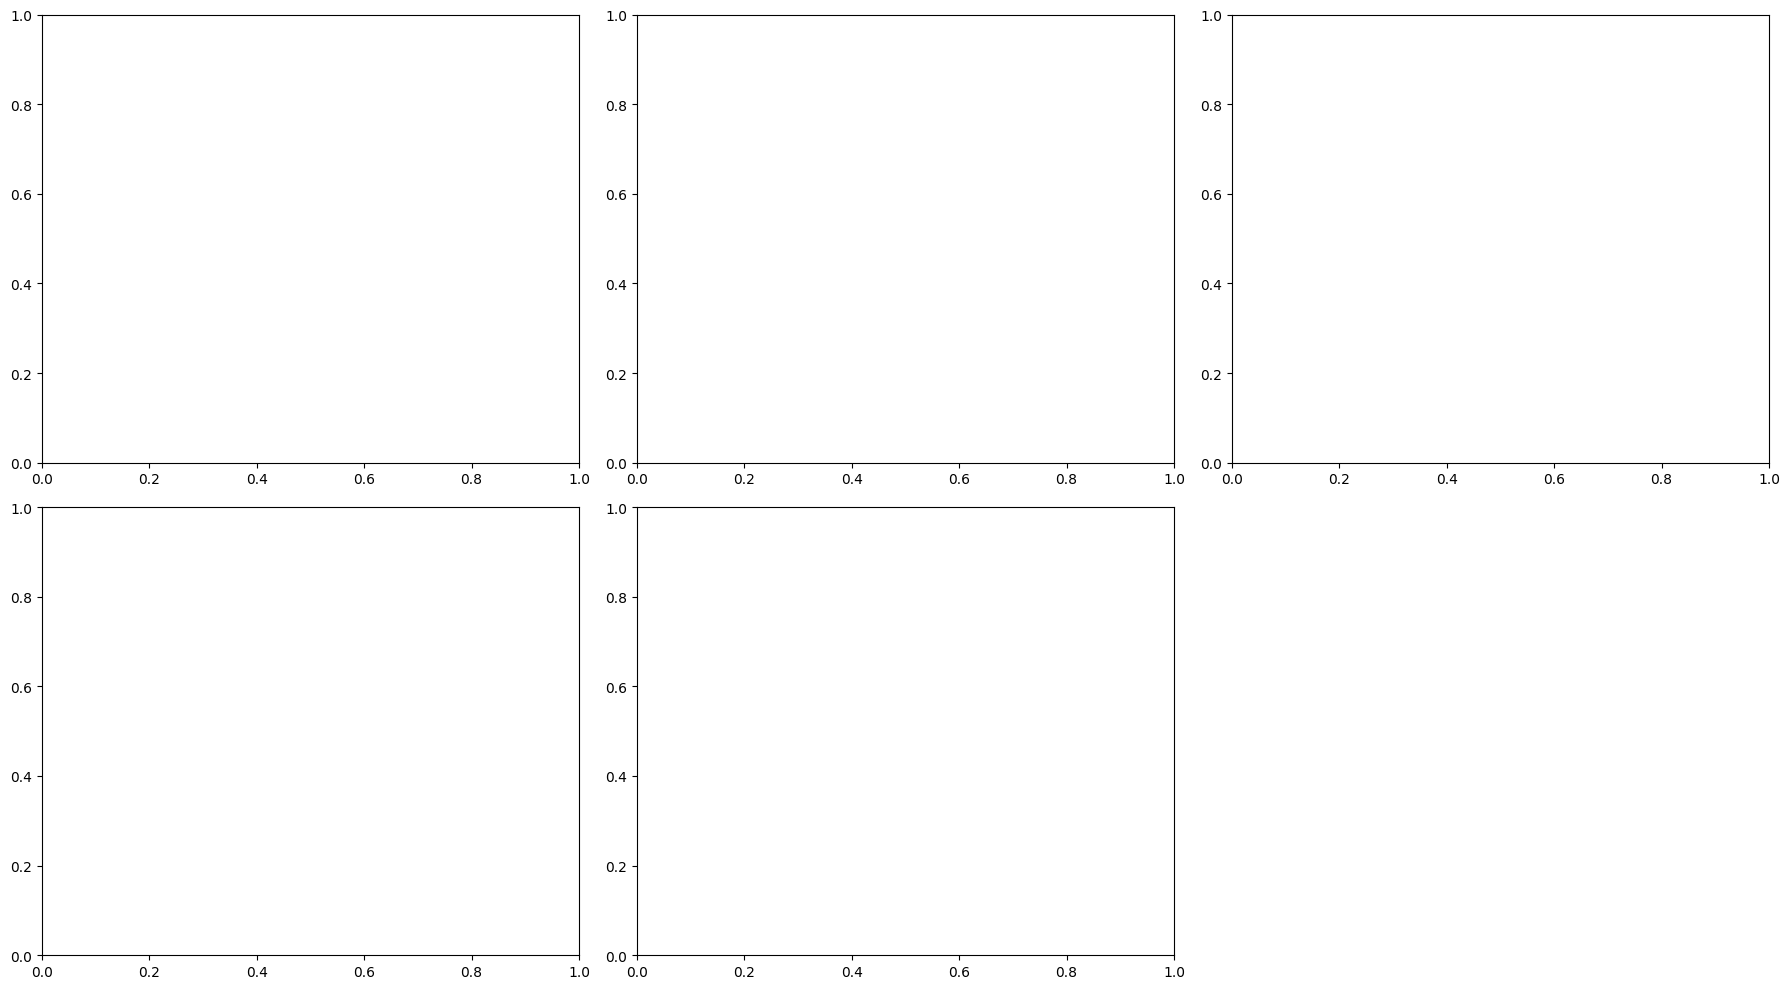

✅ Training curves saved


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (model_name, history) in enumerate(all_histories.items()):
    ax = axes[idx]
    
    ax.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
    ax.plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name} - Loss Progression', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('training_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training curves saved")

## 8️⃣ Load Best Models and Evaluate

In [13]:
# Load best models from Phase 2 (ResNet50 and DenseNet201 only)
model_configs = [
    ('ResNet50', ResNet50Seg),
    ('DenseNet201', DenseNet201Seg)
]

best_models = {}

for model_name, ModelClass in model_configs:
    model = ModelClass(num_classes=NUM_CLASSES).to(DEVICE)
    checkpoint_path = f'best_{model_name}_phase2.pth'
    try:
        model.load_state_dict(torch.load(checkpoint_path))
        print(f"✅ Loaded {model_name} from Phase 2")
    except:
        checkpoint_path = f'best_{model_name}_phase1.pth'
        try:
            model.load_state_dict(torch.load(checkpoint_path))
            print(f"✅ Loaded {model_name} from Phase 1")
        except:
            print(f"⚠️ Could not load {model_name}, using last state")
    
    best_models[model_name] = model

print("\n✅ Best models loaded")

✅ Loaded ResNet50 from Phase 1
✅ Loaded DenseNet201 from Phase 1

✅ Best models loaded


## 9️⃣ Performance Metrics Computation

In [10]:
def compute_iou(pred, label):
    """Compute mean IoU across classes"""
    iou_scores = []
    for cls in np.unique(label):
        pred_mask = pred == cls
        label_mask = label == cls
        intersection = np.logical_and(pred_mask, label_mask).sum()
        union = np.logical_or(pred_mask, label_mask).sum()
        if union > 0:
            iou_scores.append(intersection / union)
    return np.mean(iou_scores) if iou_scores else 0

print("📊 Evaluating models on validation set...\n")

evaluation_results = []

with torch.no_grad():
    for model_name, model in best_models.items():
        model.eval()
        
        val_loss = 0
        correct = 0
        total = 0
        iou_scores = []
        inference_times = []
        
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            start = time.time()
            outputs = model(images)
            inference_times.append(time.time() - start)
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.numel()
            
            # Compute IoU for this batch
            for i in range(preds.shape[0]):
                iou = compute_iou(preds[i].cpu().numpy(), labels[i].cpu().numpy())
                iou_scores.append(iou)
        
        val_loss /= len(val_loader)
        accuracy = correct / total
        mean_iou = np.mean(iou_scores)
        avg_inference = np.mean(inference_times) * 1000  # Convert to ms
        fps = 1000 / avg_inference if avg_inference > 0 else 0
        
        params = sum(p.numel() for p in model.parameters()) / 1e6
        
        evaluation_results.append({
            'Model': model_name,
            'Val Loss': f"{val_loss:.4f}",
            'Accuracy': f"{accuracy:.4f}",
            'IoU': f"{mean_iou:.4f}",
            'Params (M)': f"{params:.1f}",
            'Inference (ms)': f"{avg_inference:.2f}",
            'FPS': f"{fps:.1f}",
            'Time (min)': f"{training_times[model_name]/60:.1f}"
        })
        
        print(f"✅ {model_name:15} | Loss: {val_loss:.4f} | Acc: {accuracy:.4f} | IoU: {mean_iou:.4f}")

print("\n✅ Evaluation complete")

📊 Evaluating models on validation set...



KeyboardInterrupt: 

## 🔟 Final Comparison Table

In [ ]:
results_df = pd.DataFrame(evaluation_results)

print("\n" + "="*100)
print("🏆 FINAL MODEL COMPARISON - ALL METRICS")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Save results
results_df.to_csv('model_comparison_results.csv', index=False)
print("\n✅ Results saved to 'model_comparison_results.csv'")

## 1️⃣1️⃣ Visualize Predictions on Test Images

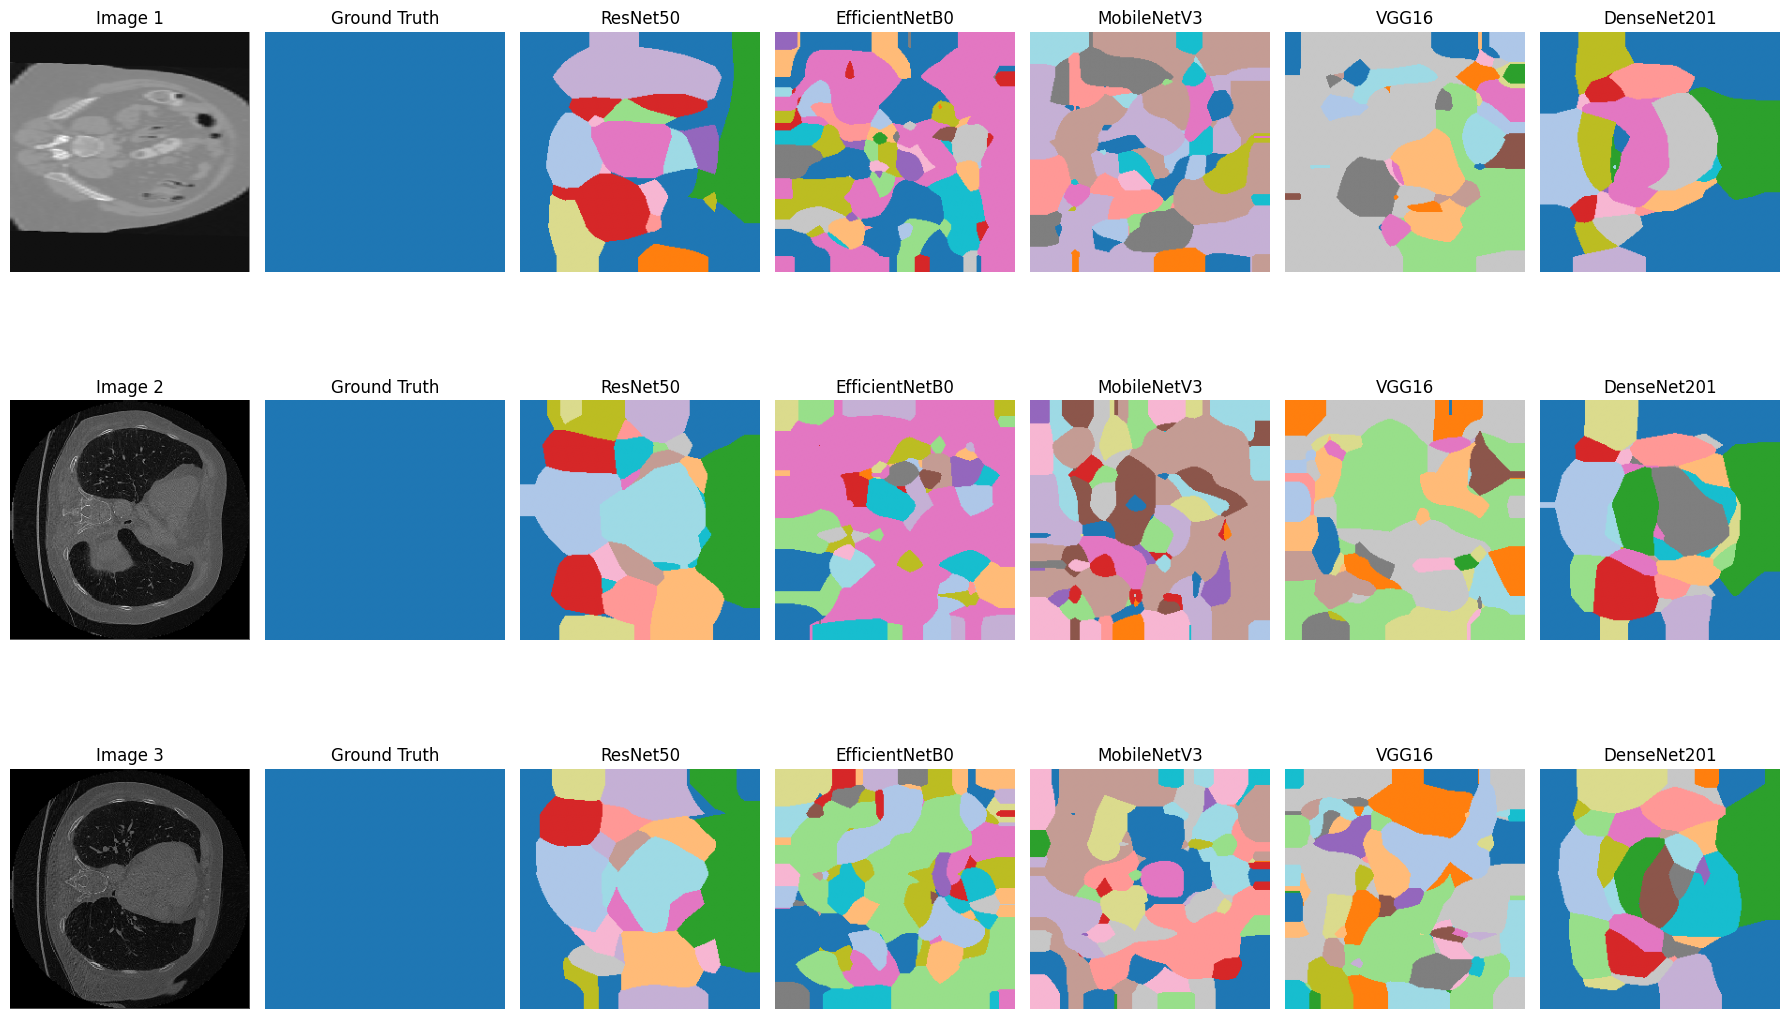

✅ Predictions visualization saved


In [ ]:
# Visualize predictions on annotated test images
num_test_samples = 4
fig, axes = plt.subplots(num_test_samples, 4, figsize=(16, 14))

val_images_list = images_np[train_size:train_size+num_test_samples]
val_labels_list = labels_2d[train_size:train_size+num_test_samples]

with torch.no_grad():
    for sample_idx in range(num_test_samples):
        # Original image
        axes[sample_idx, 0].imshow(val_images_list[sample_idx], cmap='gray')
        axes[sample_idx, 0].set_title(f'Image {sample_idx+1}', fontsize=11, fontweight='bold')
        axes[sample_idx, 0].axis('off')
        
        # Ground truth (annotated label)
        im1 = axes[sample_idx, 1].imshow(val_labels_list[sample_idx], cmap='tab20')
        axes[sample_idx, 1].set_title(f'Ground Truth (Annotated)', fontsize=11, fontweight='bold')
        axes[sample_idx, 1].axis('off')
        plt.colorbar(im1, ax=axes[sample_idx, 1], fraction=0.046, pad=0.04)
        
        # Model predictions
        img_tensor = torch.from_numpy(np.stack([val_images_list[sample_idx]]*3, axis=0)).unsqueeze(0).to(DEVICE)
        
        for model_idx, (model_name, model) in enumerate(best_models.items()):
            output = model(img_tensor)
            pred = output.argmax(dim=1).squeeze().cpu().numpy()
            
            im2 = axes[sample_idx, model_idx+2].imshow(pred, cmap='tab20')
            
            # Compute IoU for this sample
            iou = compute_iou(pred, val_labels_list[sample_idx])
            axes[sample_idx, model_idx+2].set_title(f'{model_name}\nIoU: {iou:.4f}', fontsize=11, fontweight='bold')
            axes[sample_idx, model_idx+2].axis('off')
            plt.colorbar(im2, ax=axes[sample_idx, model_idx+2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('predictions_resnet_densenet.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Annotated predictions visualization saved as 'predictions_resnet_densenet.png'")

## 1️⃣2️⃣ Recommendations Summary

In [ ]:
print("\n" + "="*100)
print("📋 TRAINING STRATEGY SUMMARY")
print("="*100)

print("\n🎯 Progressive Unfreezing Strategy Used:")
print("-" * 100)
print("Phase 1 (5 epochs):   Freeze backbone, train ONLY segmentation head (LR=1e-3)")
print("                      → Model adapts head to new task while preserving ImageNet knowledge")
print("\nPhase 2 (10 epochs):  Unfreeze last layers, fine-tune entire model (LR=1e-4)")
print("                      → Gentle adaptation of backbone to segmentation task")
print("                      → 10x lower learning rate prevents forgetting")

print("\n" + "="*100)
print("🏆 PERFORMANCE RANKING")
print("="*100)

# Sort by IoU
sorted_results = sorted(evaluation_results, key=lambda x: float(x['IoU']), reverse=True)
print(f"\nBy IoU (Segmentation Quality):")
for i, result in enumerate(sorted_results[:3], 1):
    print(f"  {i}. {result['Model']:15} - IoU: {result['IoU']}, Acc: {result['Accuracy']}")

# Sort by speed
sorted_results_speed = sorted(evaluation_results, key=lambda x: float(x['FPS']), reverse=True)
print(f"\nBy Speed (FPS):")
for i, result in enumerate(sorted_results_speed[:3], 1):
    print(f"  {i}. {result['Model']:15} - FPS: {result['FPS']:>5}, Params: {result['Params (M)']:>5}M")

# Sort by efficiency (IoU/params)
print(f"\nBy Efficiency (IoU per Million Parameters):")
efficiency = []
for result in evaluation_results:
    iou = float(result['IoU'])
    params = float(result['Params (M)'])
    efficiency.append((result['Model'], iou/params if params > 0 else 0))
efficiency.sort(key=lambda x: x[1], reverse=True)
for i, (model_name, eff) in enumerate(efficiency[:3], 1):
    print(f"  {i}. {model_name:15} - {eff:.4f} IoU/M params")

print("\n" + "="*100)
print("💡 RECOMMENDATIONS")
print("="*100)
print("\n✅ Choose EfficientNetB0 if:    You want balanced performance and small model size")
print("✅ Choose MobileNetV3 if:       You need real-time inference or edge deployment")
print("✅ Choose ResNet50 if:          You need best accuracy without extreme size")
print("✅ Choose DenseNet201 if:       You want highest accuracy and have compute resources")
print("✅ Choose VGG16 if:            You prefer simple, interpretable architecture")

print("\n" + "="*100)